In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("Microsoft_Stock.csv")
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


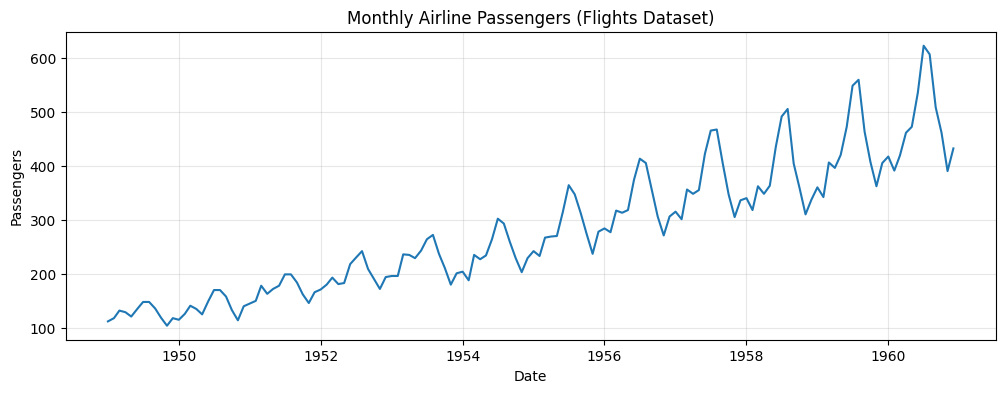

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

ts = df['Close'].asfreq('D')
ts.name = 'Close Price'

plt.figure(figsize=(12, 4))
plt.plot(ts, color='tab:blue')
plt.title('Microsoft Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(alpha=0.3)
plt.show()

ts.head()

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
ts_values = ts.values.reshape(-1, 1)
ts_scaled = scaler.fit_transform(ts_values)

print('Original range:', ts_values.min(), '-', ts_values.max())
print('Scaled range:', ts_scaled.min(), '-', ts_scaled.max())

Original min/max: 104 622
Scaled min/max: 0.0 1.0


In [ ]:
def create_sequences(data, window_size=12):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(ts_scaled, window_size=window_size)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f'Samples: {len(X)} | Train: {X_train.shape} | Test: {X_test.shape}')

Window size: 12
Total samples: 132
X_train shape: (105, 12)
y_train shape: (105,)
X_test shape: (27, 12)
y_test shape: (27,)


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

baseline_mlp = MLPRegressor(
    hidden_layer_sizes=(64,),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=16,
    max_iter=1000,
    random_state=42
)

baseline_mlp.fit(X_train, y_train)
y_train_pred = baseline_mlp.predict(X_train)
y_test_pred = baseline_mlp.predict(X_test)

## Models

In [ ]:
def evaluate_regression(y_true, y_pred, scaler):
    y_true_inv = scaler.inverse_transform(y_true.reshape(-1, 1)).ravel()
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1)).ravel()
    
    mse = mean_squared_error(y_true_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    return mse, rmse, mae, y_true_inv, y_pred_inv

train_mse, train_rmse, train_mae, y_train_inv, y_train_pred_inv = evaluate_regression(y_train, y_train_pred, scaler)
test_mse, test_rmse, test_mae, y_test_inv, y_test_pred_inv = evaluate_regression(y_test, y_test_pred, scaler)

print('Baseline MLP')
print(f'Train | MSE: {train_mse:.3f} | RMSE: {train_rmse:.3f} | MAE: {train_mae:.3f}')
print(f'Test  | MSE: {test_mse:.3f} | RMSE: {test_rmse:.3f} | MAE: {test_mae:.3f}')

Baseline MLP Performance
------------------------------
Train -> MSE: 602.277 | RMSE: 24.541 | MAE: 19.021
Test  -> MSE: 2487.393 | RMSE: 49.874 | MAE: 40.089


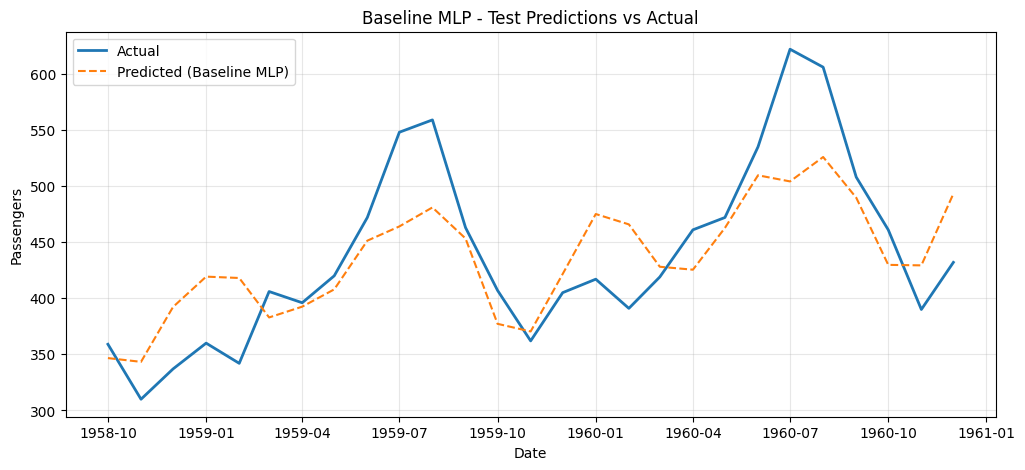

In [ ]:
test_dates = ts.index[window_size + split_idx:]

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test_inv, label='Actual', linewidth=2)
plt.plot(test_dates, y_test_pred_inv, label='Predicted', linestyle='--')
plt.title('Baseline MLP - Test Set')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
!pip install torch

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

val_ratio = 0.2
val_idx = int(len(X_train) * (1 - val_ratio))
X_tr, X_val = X_train[:val_idx], X_train[val_idx:]
y_tr, y_val = y_train[:val_idx], y_train[val_idx:]

print(f'Train: {X_tr.shape} | Validation: {X_val.shape}')

Train subset: (84, 12) (84,)
Validation subset: (21, 12) (21,)


In [ ]:
def build_tf_mlp(input_dim, hidden_units=64, dropout_rate=0.1, activation='relu', learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(hidden_units, activation=activation),
        layers.Dropout(dropout_rate),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return model


In [ ]:
model = build_tf_mlp(
    input_dim=X_tr.shape[1],
    hidden_units=64,
    dropout_rate=0.1,
    activation='relu',
    learning_rate=0.001
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'Best val_loss: {min(history.history["val_loss"]):.6f}')

Training finished.
Best val_loss: 0.001092


In [ ]:
y_test_pred_best = model.predict(X_test, verbose=0).ravel()

test_mse_best, test_rmse_best, test_mae_best, y_test_inv_best, y_test_pred_inv_best = evaluate_regression(
    y_test, y_test_pred_best, scaler
)

print('TensorFlow MLP')
print(f'MSE: {test_mse_best:.3f} | RMSE: {test_rmse_best:.3f} | MAE: {test_mae_best:.3f}')

TensorFlow MLP Performance (Test)
----------------------------------------
MSE : 342.075
RMSE: 18.495
MAE : 14.543


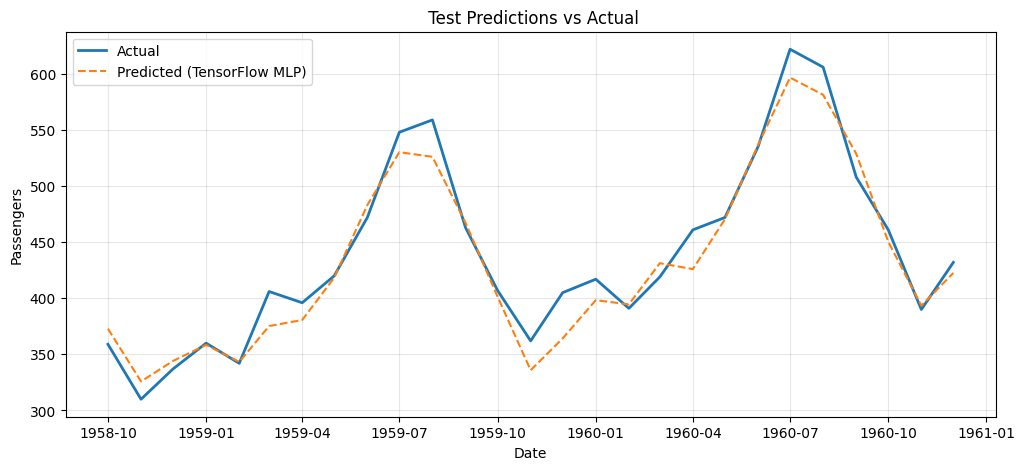

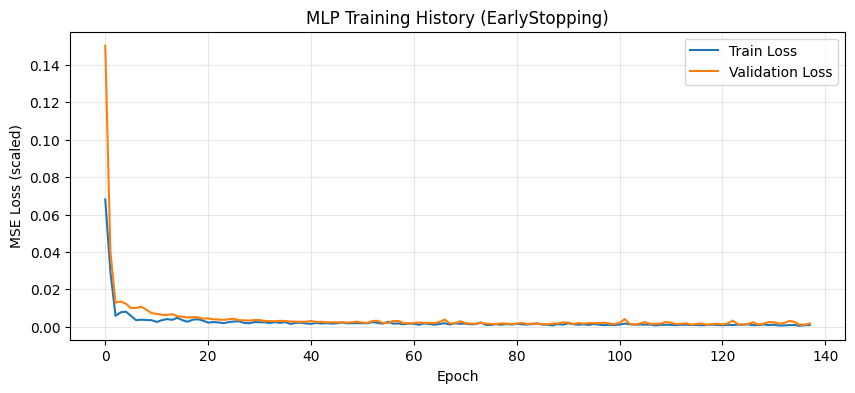

In [ ]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_best, label='Actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_best, label='Predicted', linestyle='--')
ax1.set_title('TensorFlow MLP - Test Set')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Training History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
X_train_rnn = X_train[..., np.newaxis]
X_test_rnn = X_test[..., np.newaxis]

val_idx = int(len(X_train_rnn) * 0.8)
X_tr, X_val = X_train_rnn[:val_idx], X_train_rnn[val_idx:]
y_tr, y_val = y_train[:val_idx], y_train[val_idx:]

print(f'RNN data shape: {X_tr.shape}')

X_tr shape: (84, 12, 1)
X_val shape: (21, 12, 1)
X_test_rnn shape: (27, 12, 1)


In [ ]:
rnn_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.SimpleRNN(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'RNN - Best val_loss: {min(history_rnn.history["val_loss"]):.6f}')

SimpleRNN training finished.
Best val_loss: 0.001189


In [ ]:
y_test_pred_rnn = rnn_model.predict(X_test_rnn, verbose=0).ravel()

rnn_test_mse, rnn_test_rmse, rnn_test_mae, y_test_inv_rnn, y_test_pred_inv_rnn = evaluate_regression(
    y_test, y_test_pred_rnn, scaler
)

print('SimpleRNN')
print(f'MSE: {rnn_test_mse:.3f} | RMSE: {rnn_test_rmse:.3f} | MAE: {rnn_test_mae:.3f}')

SimpleRNN Performance (Test)
-----------------------------------
MSE : 2607.676
RMSE: 51.065
MAE : 43.717


In [ ]:
comparison_df = pd.DataFrame([
    {'Model': 'MLP (Baseline)', 'MSE': test_mse, 'RMSE': test_rmse, 'MAE': test_mae},
    {'Model': 'SimpleRNN', 'MSE': rnn_test_mse, 'RMSE': rnn_test_rmse, 'MAE': rnn_test_mae}
])

print('\nComparison')
print(comparison_df)


Model Comparison on Test Set
            Model          MSE       RMSE        MAE
0  MLP (Baseline)  2487.392744  49.873768  40.089047
1       SimpleRNN  2607.675852  51.065408  43.717468


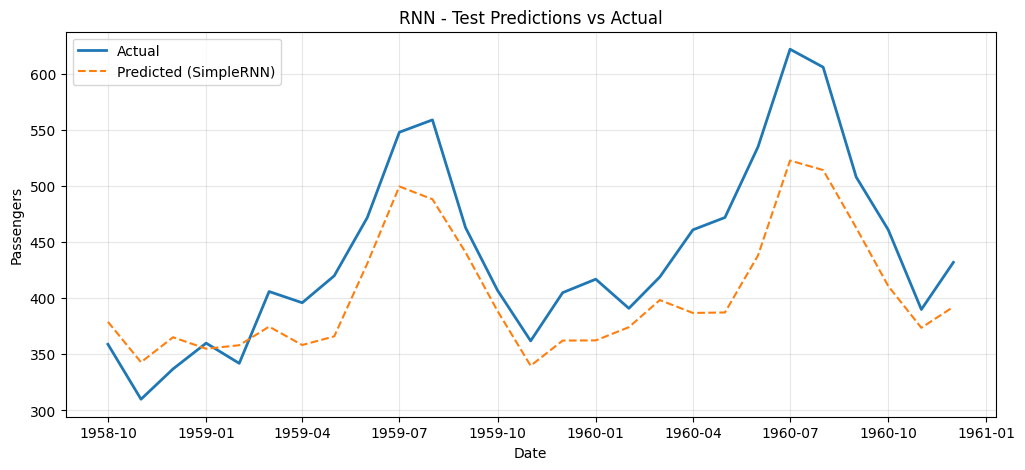

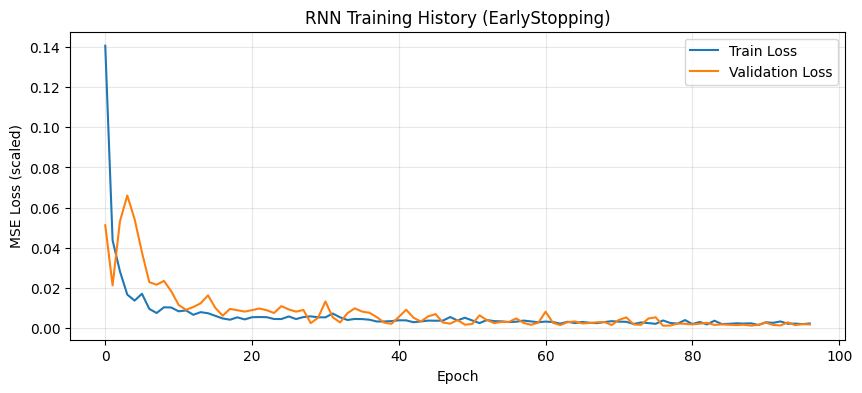

In [ ]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_rnn, label='Actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_rnn, label='Predicted', linestyle='--')
ax1.set_title('SimpleRNN - Test Set')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_rnn.history['loss'], label='Train Loss')
ax2.plot(history_rnn.history['val_loss'], label='Validation Loss')
ax2.set_title('Training History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
X_train_lstm = X_train[..., np.newaxis]
X_test_lstm = X_test[..., np.newaxis]

val_idx = int(len(X_train_lstm) * 0.8)
X_tr, X_val = X_train_lstm[:val_idx], X_train_lstm[val_idx:]
y_tr, y_val = y_train[:val_idx], y_train[val_idx:]

print(f'LSTM data shape: {X_tr.shape}')

X_tr shape: (84, 12, 1)
X_val shape: (21, 12, 1)
X_test_lstm shape: (27, 12, 1)


In [ ]:
lstm_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.LSTM(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'LSTM - Best val_loss: {min(history_lstm.history["val_loss"]):.6f}')

LSTM training finished.
Best val_loss: 0.001880


In [ ]:
y_test_pred_lstm = lstm_model.predict(X_test_lstm, verbose=0).ravel()

lstm_test_mse, lstm_test_rmse, lstm_test_mae, y_test_inv_lstm, y_test_pred_inv_lstm = evaluate_regression(
    y_test, y_test_pred_lstm, scaler
)

print('LSTM')
print(f'MSE: {lstm_test_mse:.3f} | RMSE: {lstm_test_rmse:.3f} | MAE: {lstm_test_mae:.3f}')

LSTM Performance (Test)
------------------------------
MSE : 3053.596
RMSE: 55.259
MAE : 45.285


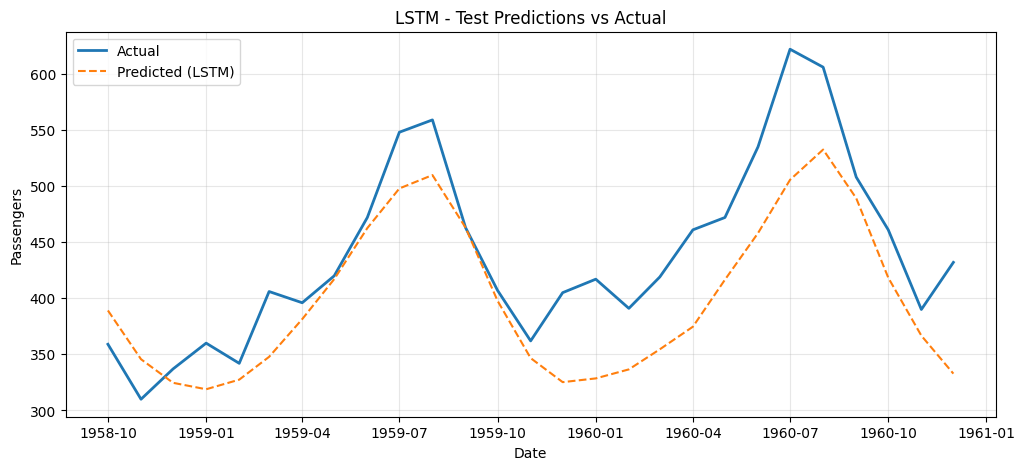

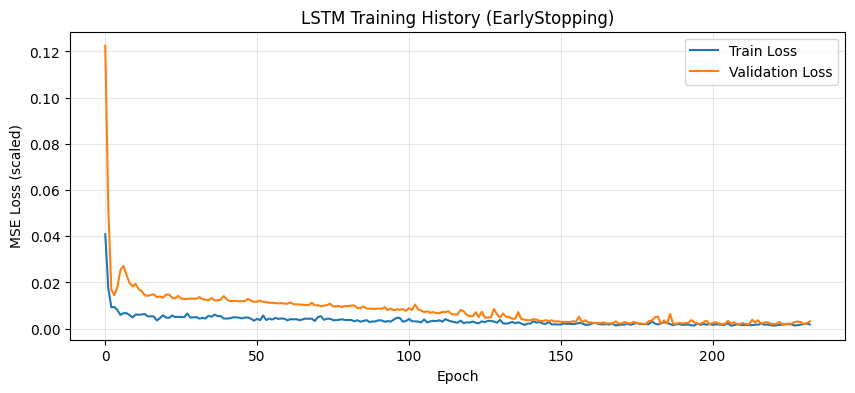

In [ ]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_lstm, label='Actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_lstm, label='Predicted', linestyle='--')
ax1.set_title('LSTM - Test Set')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_lstm.history['loss'], label='Train Loss')
ax2.plot(history_lstm.history['val_loss'], label='Validation Loss')
ax2.set_title('Training History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
X_train_gru = X_train[..., np.newaxis]
X_test_gru = X_test[..., np.newaxis]

val_idx = int(len(X_train_gru) * 0.8)
X_tr_gru, X_val_gru = X_train_gru[:val_idx], X_train_gru[val_idx:]
y_tr_gru, y_val_gru = y_train[:val_idx], y_train[val_idx:]

gru_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.GRU(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

gru_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

X_tr_gru shape: (84, 12, 1)
X_val_gru shape: (21, 12, 1)
X_test_gru shape: (27, 12, 1)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_3 (GRU)                     │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_gru = gru_model.fit(
    X_tr_gru, y_tr_gru,
    validation_data=(X_val_gru, y_val_gru),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'GRU - Best val_loss: {min(history_gru.history["val_loss"]):.6f}')

Best val_loss: 0.003431



GRU Performance (Test)
------------------------------
MSE : 1381.381
RMSE: 37.167
MAE : 29.670

Model Comparison on Test Set
            Model          MSE       RMSE        MAE
0  MLP (Baseline)  2487.392744  49.873768  40.089047
1       SimpleRNN  2607.675852  51.065408  43.717468
2             GRU  2065.988762  45.453149  37.765776
3             GRU  1381.380793  37.166931  29.670226


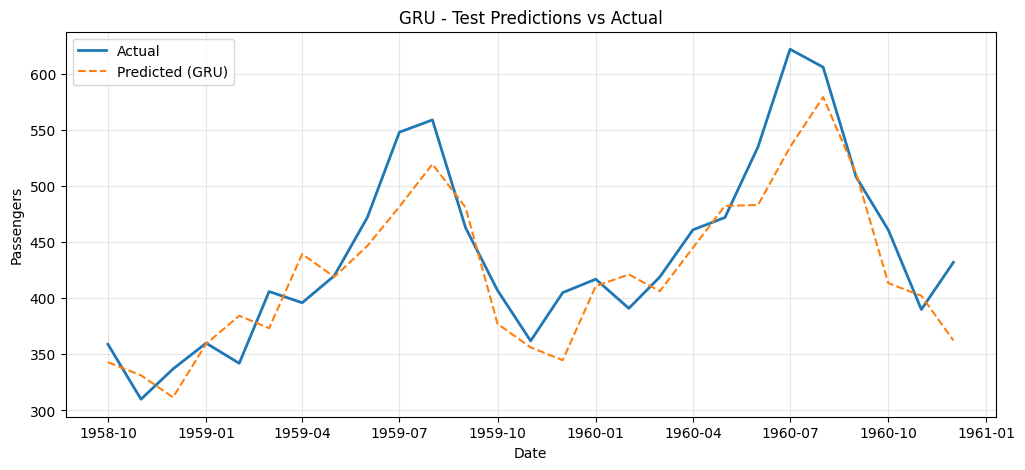

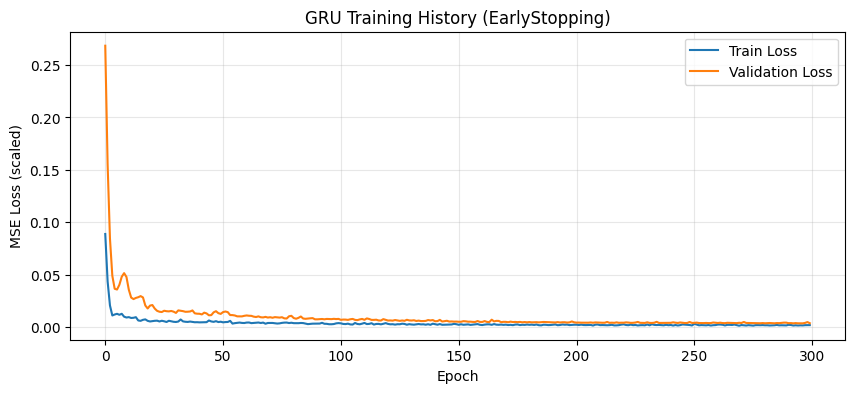

In [ ]:
y_test_pred_gru = gru_model.predict(X_test_gru, verbose=0).ravel()

gru_test_mse, gru_test_rmse, gru_test_mae, y_test_inv_gru, y_test_pred_inv_gru = evaluate_regression(
    y_test, y_test_pred_gru, scaler
)

print('GRU')
print(f'MSE: {gru_test_mse:.3f} | RMSE: {gru_test_rmse:.3f} | MAE: {gru_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'Model': 'GRU', 'MSE': gru_test_mse, 'RMSE': gru_test_rmse, 'MAE': gru_test_mae}])
], ignore_index=True)

print('\nComparison')
print(comparison_df)

test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_gru, label='Actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_gru, label='Predicted', linestyle='--')
ax1.set_title('GRU - Test Set')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_gru.history['loss'], label='Train Loss')
ax2.plot(history_gru.history['val_loss'], label='Validation Loss')
ax2.set_title('Training History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

# PART 6 - Conv1D Model

In [ ]:
X_train_cnn = X_train_gru
X_test_cnn = X_test_gru

val_idx = int(len(X_train_cnn) * 0.8)
X_tr_cnn, X_val_cnn = X_train_cnn[:val_idx], X_train_cnn[val_idx:]
y_tr_cnn, y_val_cnn = y_train[:val_idx], y_train[val_idx:]

conv1d_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(1)
])

conv1d_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

conv1d_model.summary()

--- PART 6 - Conv1D Model ---
X_tr_cnn shape: (84, 12, 1)
X_val_cnn shape: (21, 12, 1)
X_test_cnn shape: (27, 12, 1)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_conv1d = conv1d_model.fit(
    X_tr_cnn, y_tr_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'Conv1D - Best val_loss: {min(history_conv1d.history["val_loss"]):.6f}')

Conv1D training finished.
Best val_loss: 0.002808


In [ ]:
y_test_pred_conv1d = conv1d_model.predict(X_test_cnn, verbose=0).ravel()

conv1d_test_mse, conv1d_test_rmse, conv1d_test_mae, y_test_inv_conv1d, y_test_pred_inv_conv1d = evaluate_regression(
    y_test, y_test_pred_conv1d, scaler
)

print('Conv1D')
print(f'MSE: {conv1d_test_mse:.3f} | RMSE: {conv1d_test_rmse:.3f} | MAE: {conv1d_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'Model': 'Conv1D', 'MSE': conv1d_test_mse, 'RMSE': conv1d_test_rmse, 'MAE': conv1d_test_mae}])
], ignore_index=True)

print('\nComparison')
print(comparison_df)


Conv1D Performance (Test)
------------------------------
MSE : 752.018
RMSE: 27.423
MAE : 23.130

Model Comparison on Test Set
            Model          MSE       RMSE        MAE
0  MLP (Baseline)  2487.392744  49.873768  40.089047
1       SimpleRNN  2607.675852  51.065408  43.717468
2             GRU  2065.988762  45.453149  37.765776
3             GRU  1381.380793  37.166931  29.670226
4          Conv1D   752.017764  27.422942  23.130336


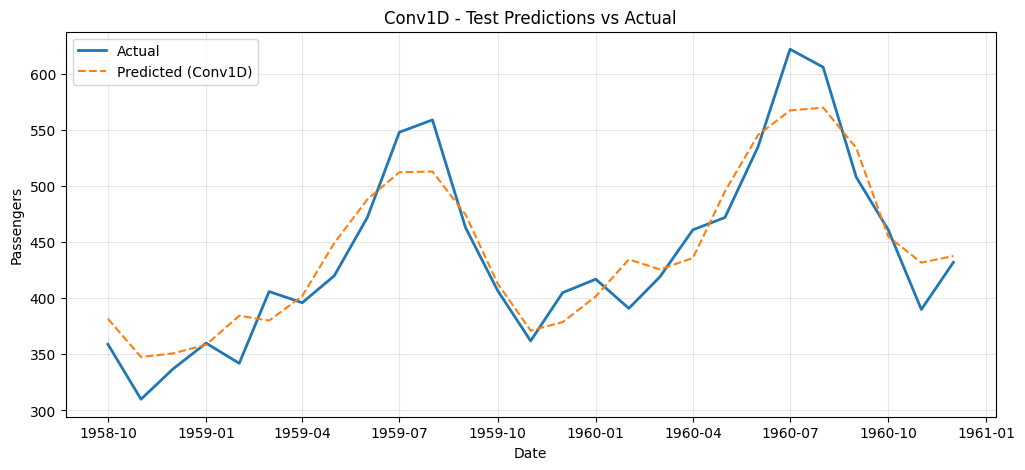

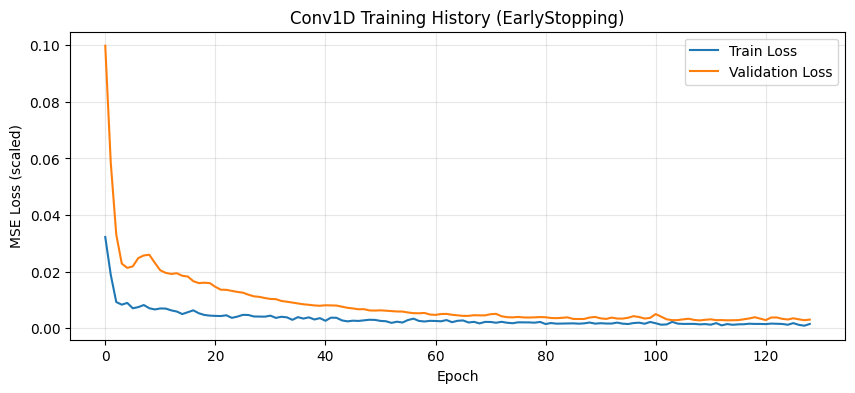

In [ ]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_conv1d, label='Actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_conv1d, label='Predicted', linestyle='--')
ax1.set_title('Conv1D - Test Set')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_conv1d.history['loss'], label='Train Loss')
ax2.plot(history_conv1d.history['val_loss'], label='Validation Loss')
ax2.set_title('Training History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
X_train_cnnlstm = X_train_gru
X_test_cnnlstm = X_test_gru

val_idx = int(len(X_train_cnnlstm) * 0.8)
X_tr_cnnlstm, X_val_cnnlstm = X_train_cnnlstm[:val_idx], X_train_cnnlstm[val_idx:]
y_tr_cnnlstm, y_val_cnnlstm = y_train[:val_idx], y_train[val_idx:]

cnnlstm_model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='causal'),
    layers.MaxPooling1D(pool_size=2),
    layers.LSTM(64, activation='tanh', recurrent_dropout=0.2),
    layers.Dropout(0.3),
    layers.Dense(1)
])

cnnlstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

cnnlstm_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

X_tr_cnnlstm shape: (84, 12, 1)
X_val_cnnlstm shape: (21, 12, 1)
X_test_cnnlstm shape: (27, 12, 1)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 12, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,345 (130.25 KB)

 Trainable params: 33,345 (130.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnnlstm = cnnlstm_model.fit(
    X_tr_cnnlstm, y_tr_cnnlstm,
    validation_data=(X_val_cnnlstm, y_val_cnnlstm),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'CNN-LSTM - Best val_loss: {min(history_cnnlstm.history["val_loss"]):.6f}')

Hybrid CNN-LSTM training finished.
Best val_loss: 0.001629



Hydrid CNN-LSTM Performance (Test)
-----------------------------------
MSE : 261.656
RMSE: 16.176
MAE : 13.537

Model Comparison on Test Set
            Model          MSE       RMSE        MAE
0  MLP (Baseline)  2487.392744  49.873768  40.089047
1       SimpleRNN  2607.675852  51.065408  43.717468
2             GRU  2065.988762  45.453149  37.765776
3             GRU  1381.380793  37.166931  29.670226
4          Conv1D   752.017764  27.422942  23.130336
5        CNN-LSTM   261.656404  16.175797  13.536615


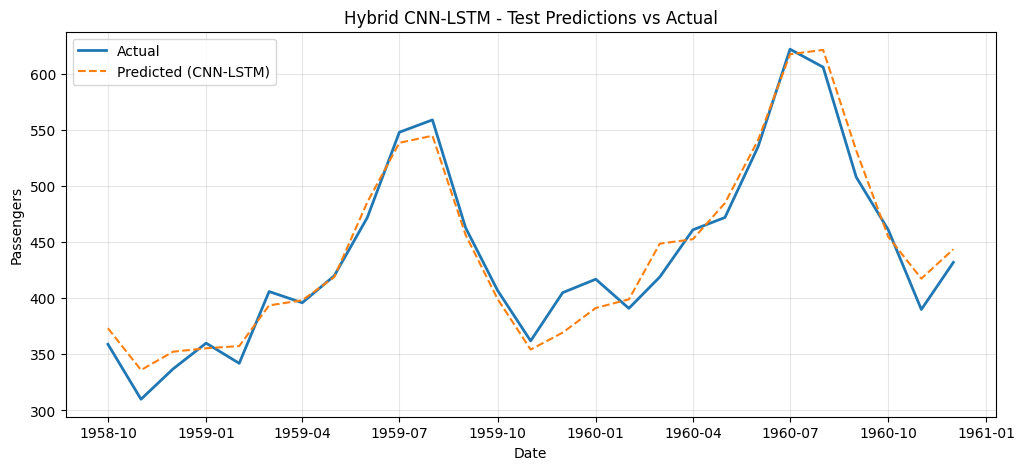

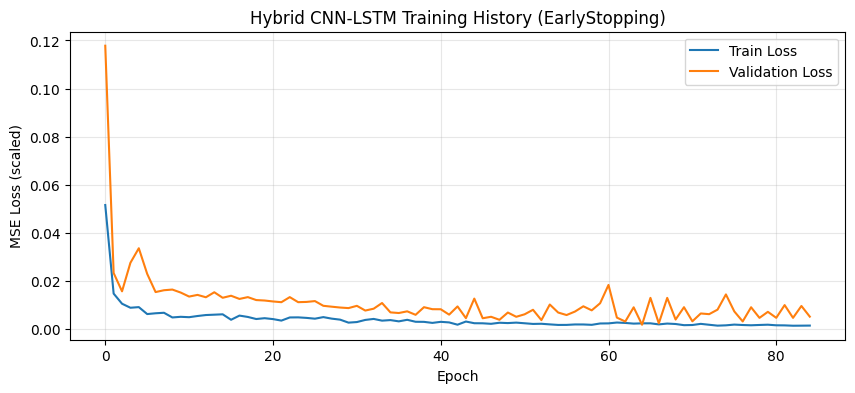

In [ ]:
y_test_pred_cnnlstm = cnnlstm_model.predict(X_test_cnnlstm, verbose=0).ravel()

cnnlstm_test_mse, cnnlstm_test_rmse, cnnlstm_test_mae, y_test_inv_cnnlstm, y_test_pred_inv_cnnlstm = evaluate_regression(
    y_test, y_test_pred_cnnlstm, scaler
)

print('CNN-LSTM')
print(f'MSE: {cnnlstm_test_mse:.3f} | RMSE: {cnnlstm_test_rmse:.3f} | MAE: {cnnlstm_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'Model': 'CNN-LSTM', 'MSE': cnnlstm_test_mse, 'RMSE': cnnlstm_test_rmse, 'MAE': cnnlstm_test_mae}])
], ignore_index=True)

print('\nComparison')
print(comparison_df)

test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_cnnlstm, label='Actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_cnnlstm, label='Predicted', linestyle='--')
ax1.set_title('CNN-LSTM - Test Set')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_cnnlstm.history['loss'], label='Train Loss')
ax2.plot(history_cnnlstm.history['val_loss'], label='Validation Loss')
ax2.set_title('Training History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
X_train_attn = X_train[..., np.newaxis]
X_test_attn = X_test[..., np.newaxis]

val_idx = int(len(X_train_attn) * 0.8)
X_tr_attn, X_val_attn = X_train_attn[:val_idx], X_train_attn[val_idx:]
y_tr_attn, y_val_attn = y_train[:val_idx], y_train[val_idx:]

lstm_units = 64

inputs = keras.Input(shape=(window_size, 1))
lstm_out = layers.LSTM(lstm_units, activation='tanh', recurrent_dropout=0.2, return_sequences=True)(inputs)
dropout_lstm = layers.Dropout(0.3)(lstm_out)

query_vec = layers.Dense(lstm_units, activation='tanh')(dropout_lstm)
attention_output = layers.AdditiveAttention()([query_vec, dropout_lstm])

attention_dim = 10
energy = layers.Dense(attention_dim, activation='tanh')(dropout_lstm)
scores = layers.Dense(1)(energy)
attention_weights = layers.Softmax(axis=1)(scores)

context_vector = layers.Multiply()([attention_weights, dropout_lstm])
context_vector = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(context_vector)

outputs = layers.Dense(1)(context_vector)

lstm_attn_model = keras.Model(inputs=inputs, outputs=outputs)
lstm_attn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

lstm_attn_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

X_tr_attn shape: (84, 12, 1)
X_val_attn shape: (21, 12, 1)
X_test_attn shape: (27, 12, 1)


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 12, 64)    │     16,896 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 12, 64)    │          0 │ lstm_4[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ energy_W (Dense)    │ (None, 12, 10)    │        650 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ energy_V (Dense)    │ (None, 12, 1)     │         11 │ energy_W[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 12, 1)     │          0 │ energy_V[0][0]    │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weighted_lstm_outp… │ (None, 12, 64)    │          0 │ attention_weight… │
│ (Multiply)          │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_vector_sum  │ (None, 64)        │          0 │ weighted_lstm_ou… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1)         │         65 │ context_vector_s… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 17,622 (68.84 KB)

 Trainable params: 17,622 (68.84 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm_attn = lstm_attn_model.fit(
    X_tr_attn, y_tr_attn,
    validation_data=(X_val_attn, y_val_attn),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'LSTM + Attention - Best val_loss: {min(history_lstm_attn.history["val_loss"]):.6f}')

LSTM with Attention training finished.
Best val_loss: 0.008246

LSTM with Attention Performance (Test)
---------------------------------------------
MSE : 4298.235
RMSE: 65.561
MAE : 46.560

Model Comparison on Test Set
              Model          MSE       RMSE        MAE
0    MLP (Baseline)  2487.392744  49.873768  40.089047
1         SimpleRNN  2607.675852  51.065408  43.717468
2               GRU  2065.988762  45.453149  37.765776
3               GRU  1381.380793  37.166931  29.670226
4            Conv1D   752.017764  27.422942  23.130336
5          CNN-LSTM   261.656404  16.175797  13.536615
6  LSTM + Attention  4298.235133  65.560927  46.559917


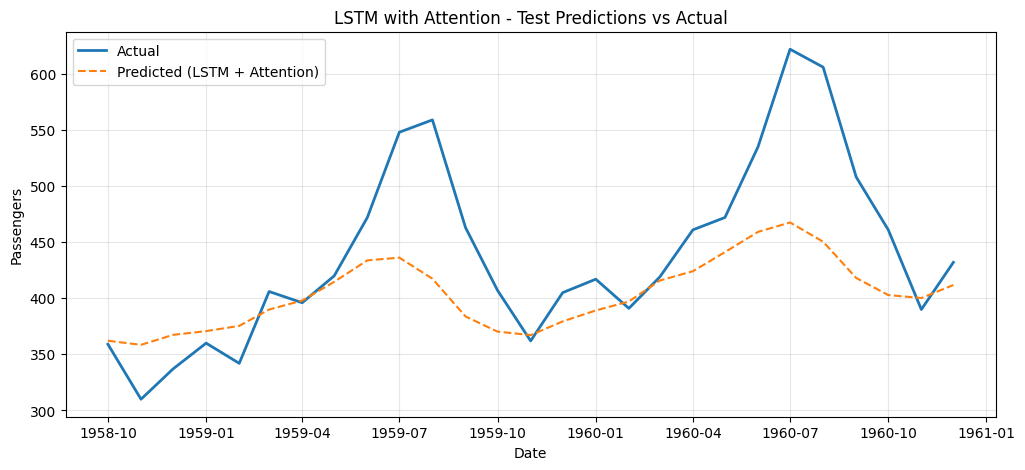

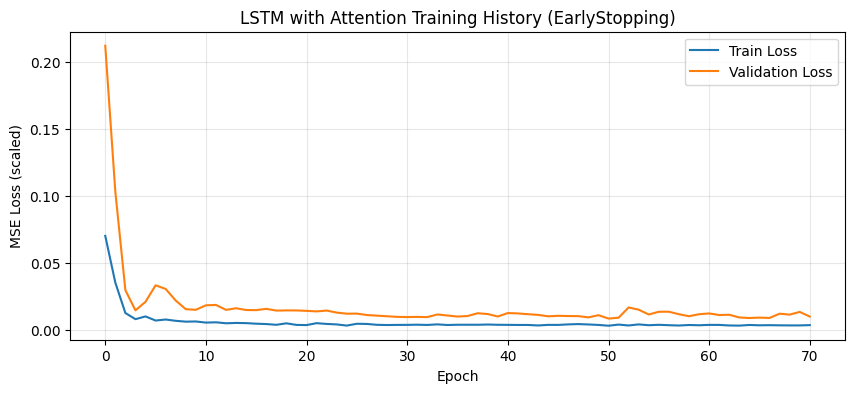

In [ ]:
y_test_pred_lstm_attn = lstm_attn_model.predict(X_test_attn, verbose=0).ravel()

lstm_attn_test_mse, lstm_attn_test_rmse, lstm_attn_test_mae, y_test_inv_lstm_attn, y_test_pred_inv_lstm_attn = evaluate_regression(
    y_test, y_test_pred_lstm_attn, scaler
)

print('LSTM + Attention')
print(f'MSE: {lstm_attn_test_mse:.3f} | RMSE: {lstm_attn_test_rmse:.3f} | MAE: {lstm_attn_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'Model': 'LSTM + Attention', 'MSE': lstm_attn_test_mse, 'RMSE': lstm_attn_test_rmse, 'MAE': lstm_attn_test_mae}])
], ignore_index=True)

print('\nComparison')
print(comparison_df)

test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_lstm_attn, label='Actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_lstm_attn, label='Predicted', linestyle='--')
ax1.set_title('LSTM + Attention - Test Set')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_lstm_attn.history['loss'], label='Train Loss')
ax2.plot(history_lstm_attn.history['val_loss'], label='Validation Loss')
ax2.set_title('Training History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

# PART 9 - Transformer Model

In [ ]:
X_train_tf = X_train[..., np.newaxis]
X_test_tf = X_test[..., np.newaxis]

val_idx = int(len(X_train_tf) * 0.8)
X_tr_tf, X_val_tf = X_train_tf[:val_idx], X_train_tf[val_idx:]
y_tr_tf, y_val_tf = y_train[:val_idx], y_train[val_idx:]

print(f'Transformer data shape: {X_tr_tf.shape}')

--- PART 9 - Transformer Model ---
X_tr_tf shape: (84, 12, 1)
X_val_tf shape: (21, 12, 1)
X_test_tf shape: (27, 12, 1)


### 1. Positional Encoding

In [ ]:
class PositionalEncoding(layers.Layer):
    def __init__(self, position, d_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.position = position
        self.d_model = d_model
        self.pos_encoding = self.positional_encoding(position, d_model)

    def get_angles(self, position, i, d_model):
        angles = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        return position * angles

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(np.arange(position)[:, np.newaxis],
                                     np.arange(d_model)[np.newaxis, :],
                                     d_model)

        # apply sin to even indices in the array; 2i
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])

        # apply cos to odd indices in the array; 2i + 1
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        pos_encoding = tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)
        return pos_encoding

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

### 2. Multi-Head Attention

In [ ]:
def scaled_dot_product_attention(query, key, value, mask):
    matmul_qk = tf.matmul(query, key, transpose_b=True)
    dk = tf.cast(tf.shape(key)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    if mask is not None:
        scaled_attention_logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
    output = tf.matmul(attention_weights, value)
    return output, attention_weights

class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(MultiHeadSelfAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        self.depth = d_model // self.num_heads

        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)

        self.dense = layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask=None):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)  # (batch_size, seq_len, d_model)
        k = self.wk(k)  # (batch_size, seq_len, d_model)
        v = self.wv(v)  # (batch_size, seq_len, d_model)

        q = self.split_heads(q, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
        k = self.split_heads(k, batch_size)  # (batch_size, num_heads, seq_len_k, depth)
        v = self.split_heads(v, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

        scaled_attention, attention_weights = scaled_dot_product_attention(
            q, k, v, mask)

        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)

        concat_attention = tf.reshape(scaled_attention,
                                      (batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

        output = self.dense(concat_attention)  # (batch_size, seq_len_q, d_model)
        return output, attention_weights

### 3. Feed Forward Network and Transformer Block

In [ ]:
def point_wise_feed_forward_network(d_model, dff):
    return keras.Sequential([
        layers.Dense(dff, activation='relu'),  # (batch_size, seq_len, dff)
        layers.Dense(d_model)  # (batch_size, seq_len, d_model)
    ])

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.ffn = point_wise_feed_forward_network(d_model, dff)

        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, x, training, mask=None):
        attn_output, _ = self.mha(x, x, x, mask)  # (batch_size, input_seq_len, d_model)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)

        ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

### 4. Transformer Model for Time Series

In [ ]:
class TimeSeriesTransformer(keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_seq_len, rate=0.1, **kwargs):
        super(TimeSeriesTransformer, self).__init__(**kwargs)
        self.d_model = d_model
        self.input_seq_len = input_seq_len

        self.embedding = layers.Dense(d_model) # Project input features to d_model
        self.pos_encoding = PositionalEncoding(input_seq_len, d_model)

        self.enc_layers = [TransformerBlock(d_model, num_heads, dff, rate) for _ in range(num_layers)]

        self.final_layer = layers.Dense(1)

    def call(self, inputs, training=False, mask=None):
        seq_len = tf.shape(inputs)[1]

        # Assuming input is (batch, sequence_length, 1) and we need to project it to d_model
        x = self.embedding(inputs)  # (batch_size, input_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = self.pos_encoding(x)

        for i in range(len(self.enc_layers)):
            x = self.enc_layers[i](x, training=training, mask=mask)

        # For time series forecasting, we typically want a single prediction output.
        # One common approach is to take the output of the last timestep of the Transformer encoder.
        # Or, pool the output, or use a dense layer on the last encoder output.
        # Here, we'll flatten the output and then use a dense layer.

        # Option 1: Take the output of the last timestep
        # x = x[:, -1, :]

        # Option 2: Flatten and then dense
        x = layers.Flatten()(x)

        output = self.final_layer(x)  # (batch_size, 1)

        return output

In [ ]:
num_layers = 2
d_model = 64
num_heads = 4
dff = 128
rate = 0.1

transformer_model = TimeSeriesTransformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_seq_len=window_size,
    rate=rate
)

transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse'
)

transformer_model.build(input_shape=X_tr_tf.shape)
transformer_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'time_series_transformer_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "time_series_transformer_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding_1           │ ?                      │   0 (unbuilt) │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ ?                      │   0 (unbuilt) │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_transformer = transformer_model.fit(
    X_tr_tf, y_tr_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=300,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop]
)

print(f'Transformer - Best val_loss: {min(history_transformer.history["val_loss"]):.6f}')

Transformer training finished.
Best val_loss: 0.001943


In [ ]:
y_test_pred_transformer = transformer_model.predict(X_test_tf, verbose=0).ravel()

transformer_test_mse, transformer_test_rmse, transformer_test_mae, y_test_inv_transformer, y_test_pred_inv_transformer = evaluate_regression(
    y_test, y_test_pred_transformer, scaler
)

print('Transformer')
print(f'MSE: {transformer_test_mse:.3f} | RMSE: {transformer_test_rmse:.3f} | MAE: {transformer_test_mae:.3f}')

comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{'Model': 'Transformer', 'MSE': transformer_test_mse, 'RMSE': transformer_test_rmse, 'MAE': transformer_test_mae}])
], ignore_index=True)

print('\nComparison')
print(comparison_df)


Transformer Performance (Test)
-----------------------------------
MSE : 2107.567
RMSE: 45.908
MAE : 36.045

Model Comparison on Test Set
              Model          MSE       RMSE        MAE
0    MLP (Baseline)  2487.392744  49.873768  40.089047
1         SimpleRNN  2607.675852  51.065408  43.717468
2               GRU  2065.988762  45.453149  37.765776
3               GRU  1381.380793  37.166931  29.670226
4            Conv1D   752.017764  27.422942  23.130336
5          CNN-LSTM   261.656404  16.175797  13.536615
6  LSTM + Attention  4298.235133  65.560927  46.559917
7       Transformer  2107.566984  45.908245  36.045166


In [ ]:
model_results = [
    {'Model': 'TensorFlow MLP', 'MSE': test_mse_best, 'RMSE': test_rmse_best, 'MAE': test_mae_best, 'Predictions': y_test_pred_inv_best},
    {'Model': 'SimpleRNN', 'MSE': rnn_test_mse, 'RMSE': rnn_test_rmse, 'MAE': rnn_test_mae, 'Predictions': y_test_pred_inv_rnn},
    {'Model': 'LSTM', 'MSE': lstm_test_mse, 'RMSE': lstm_test_rmse, 'MAE': lstm_test_mae, 'Predictions': y_test_pred_inv_lstm},
    {'Model': 'GRU', 'MSE': gru_test_mse, 'RMSE': gru_test_rmse, 'MAE': gru_test_mae, 'Predictions': y_test_pred_inv_gru},
    {'Model': 'Conv1D', 'MSE': conv1d_test_mse, 'RMSE': conv1d_test_rmse, 'MAE': conv1d_test_mae, 'Predictions': y_test_pred_inv_conv1d},
    {'Model': 'CNN-LSTM', 'MSE': cnnlstm_test_mse, 'RMSE': cnnlstm_test_rmse, 'MAE': cnnlstm_test_mae, 'Predictions': y_test_pred_inv_cnnlstm},
    {'Model': 'LSTM + Attention', 'MSE': lstm_attn_test_mse, 'RMSE': lstm_attn_test_rmse, 'MAE': lstm_attn_test_mae, 'Predictions': y_test_pred_inv_lstm_attn},
    {'Model': 'Transformer', 'MSE': transformer_test_mse, 'RMSE': transformer_test_rmse, 'MAE': transformer_test_mae, 'Predictions': y_test_pred_inv_transformer}
]

comparison_df_plot = pd.DataFrame(model_results)

print('Final Results')
print(comparison_df_plot.drop(columns=['Predictions']))


Updated Model Comparison on Test Set
              Model          MSE       RMSE        MAE
0    TensorFlow MLP   342.075241  18.495276  14.542918
1         SimpleRNN  2607.675852  51.065408  43.717468
2              LSTM  3053.595621  55.259349  45.284519
3               GRU  1381.380793  37.166931  29.670226
4            Conv1D   752.017764  27.422942  23.130336
5          CNN-LSTM   261.656404  16.175797  13.536615
6  LSTM + Attention  4298.235133  65.560927  46.559917
7       Transformer  2107.566984  45.908245  36.045166


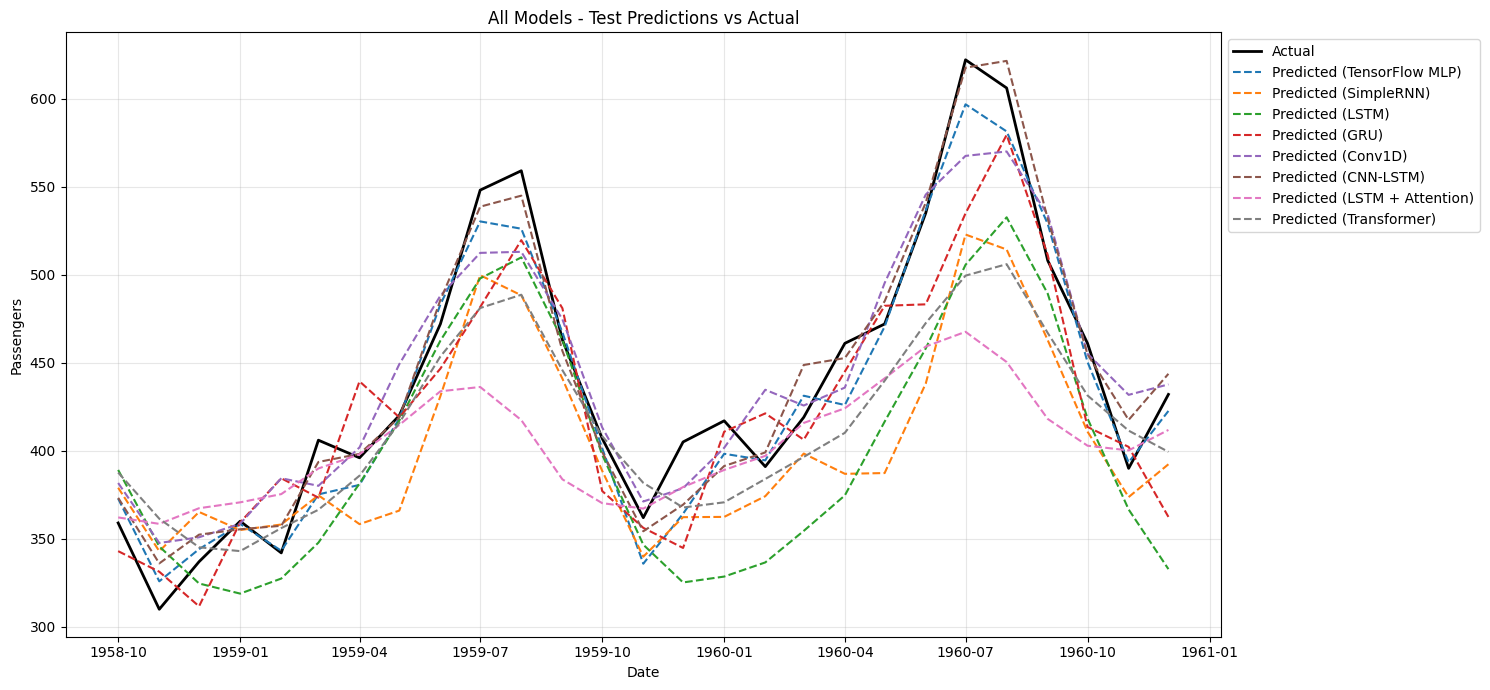

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(test_dates, y_test_inv, label='Actual', color='black', linewidth=2)

for index, row in comparison_df_plot.iterrows():
    plt.plot(test_dates, row['Predictions'], label=row['Model'], linestyle='--')

plt.title('All Models - Test Set Comparison')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

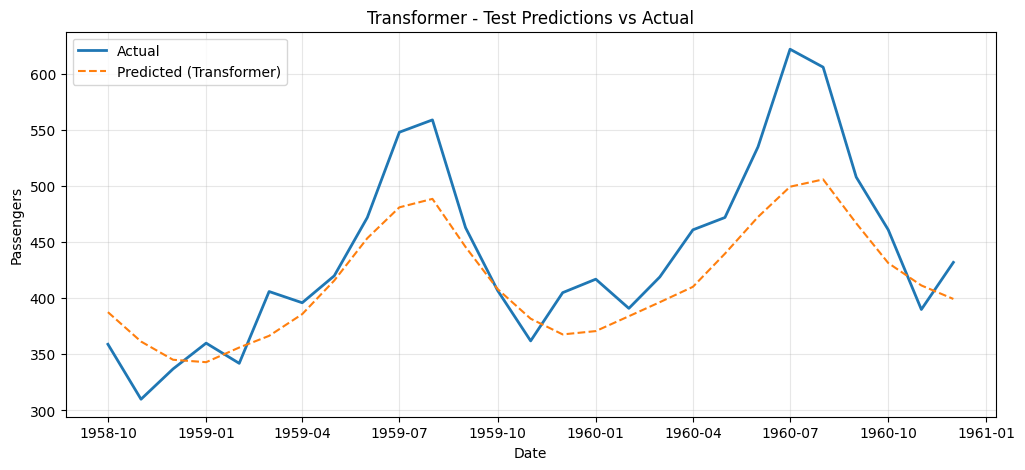

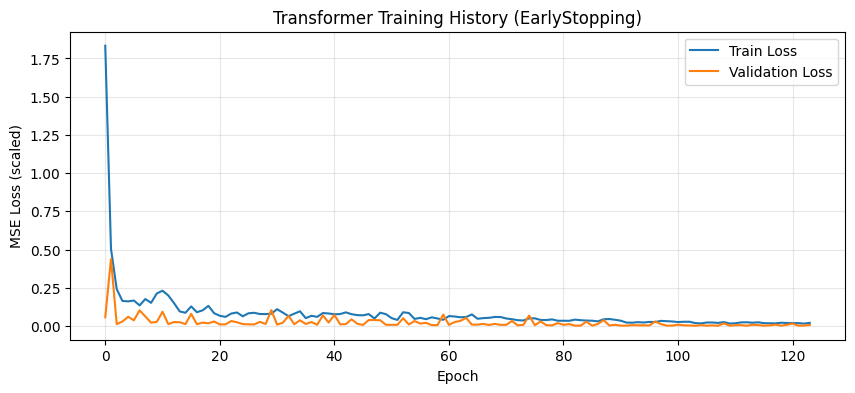

In [ ]:
test_dates = ts.index[window_size + split_idx:]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(test_dates, y_test_inv_transformer, label='Actual', linewidth=2)
ax1.plot(test_dates, y_test_pred_inv_transformer, label='Predicted', linestyle='--')
ax1.set_title('Transformer - Test Set')
ax1.set_ylabel('Price ($)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history_transformer.history['loss'], label='Train Loss')
ax2.plot(history_transformer.history['val_loss'], label='Validation Loss')
ax2.set_title('Training History')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()